# ChoiceIQ Notebook 3 — Recommendation Demo

This notebook demonstrates exactly what happens after a user submits the five-question quiz.

In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
BASE=Path('..').resolve()
DATA=BASE/'Data'/'processed'
MODELS=BASE/'models'
careers=pd.read_csv(DATA/'choiceiq_careers.csv')
model=joblib.load(MODELS/'cosine_knn.joblib')
FEATURES=['data_analytics','programming','mathematics','cybersecurity','networking','problem_solving','creativity_design','systems_cloud','communication_business']

## Example user
Suppose a student shows strong interest in data, mathematics and problem solving.

In [2]:
user_vector=np.array([1.0,0.45,0.9,0.0,0.0,0.8,0.1,0.2,0.2])
pd.Series(user_vector,index=FEATURES,name='user_score')

data_analytics            1.00
programming               0.45
mathematics               0.90
cybersecurity             0.00
networking                0.00
problem_solving           0.80
creativity_design         0.10
systems_cloud             0.20
communication_business    0.20
Name: user_score, dtype: float64

## Query the saved cosine k-NN model

In [3]:
distances, indices = model.kneighbors([user_vector], n_neighbors=3)
results=careers.iloc[indices[0]].copy()
results['match_percent']=((1-distances[0])*100).round(1)
results[['career','match_percent','sa_validation_status','sa_official_match']]

,career,match_percent,sa_validation_status,sa_official_match
7,Data Analyst,94.9,Not directly matched in supplied lists,NaN
9,Data Scientist,92.1,Exact official occupation,Data Scientist
8,Data Engineer,85.8,Not directly matched in supplied lists,NaN


## Interpretation
Cosine similarity compares the direction of the user and career vectors. A higher value means the pattern of interests is more similar to the career profile. South African validation is displayed after ranking and does not affect the match score.

## Recommendation explanation visual

This chart compares the example student profile with the top recommended career.

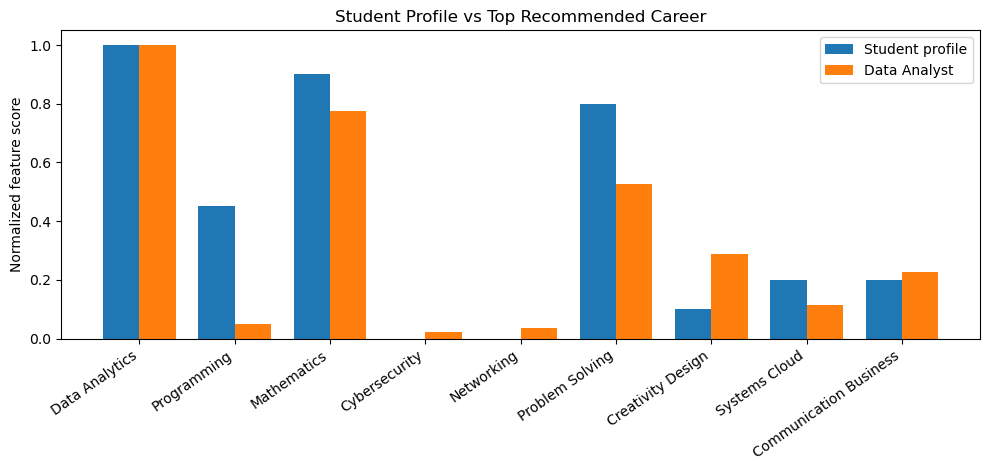

In [4]:
import matplotlib.pyplot as plt
top=results.iloc[0]; career_vector=top[FEATURES].to_numpy(dtype=float); labels=[f.replace('_',' ').title() for f in FEATURES]; x=np.arange(len(FEATURES)); width=0.38
plt.figure(figsize=(10,4.8)); plt.bar(x-width/2,user_vector,width,label='Student profile'); plt.bar(x+width/2,career_vector,width,label=str(top['career'])); plt.xticks(x,labels,rotation=35,ha='right'); plt.ylabel('Normalized feature score'); plt.title('Student Profile vs Top Recommended Career'); plt.ylim(0,1.05); plt.legend(); plt.tight_layout(); plt.savefig(BASE/'assets'/'figures'/'05_user_vs_top_career.png',dpi=160); plt.show()